# Step timing: coarse mesh, coarse mesh + refinement, fine mesh

Wall-clock cost per simulation step for the three mesh conditions used in the loss studies
(`refinement_loss.ipynb`, `refinement_loss_episodes.ipynb`), parsed from the `Step and readback took … ms`
lines that `sim_octopus` prints. All runs share the solver settings of their episode and ran on the same
RTX 4060 Laptop GPU, so the numbers are directly comparable within an episode.

| episode | without refinement | with refinement | fine mesh |
|---|---|---|---|
| octopus | `sweep_refine_corr_fine_geometric_work/log_norefine*.txt` (3 repeats) | `…/log_refine_every=10*.txt` — the best geometric setting of that sweep (3 repeats) | `reference_runs/fine_default.log` |
| dice / turtle / tp_roll | `refinement_loss_runs/logs/<ep>_norefine_r{1,2,3}.log` | `…/<ep>_refine_r{1,2,3}.log` | `…/<ep>_fine.log` |

"Step and readback" is one full frame: all Newton iterations + substeps, the refinement pass (when it
fires), and the GPU→host copy for recording. The first step includes Warp kernel compilation / graph
capture and is dropped from the summaries.

In [1]:
import os, re, sys, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path(os.environ.get("WARP_MFEM_ROOT", Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent))
os.chdir(ROOT)

SWEEP = ROOT / "sweep_refine_corr_fine_geometric_work"
LOGS = ROOT / "refinement_loss_runs" / "logs"
RUNS = {
    "octopus": {
        "without refinement": sorted(SWEEP.glob("log_norefine*.txt")),
        "with refinement": sorted(SWEEP.glob("log_refine_every=10.txt")) + sorted(SWEEP.glob("log_refine_every=10_r?.txt")),
        "fine mesh (no refinement)": [ROOT / "reference_runs" / "fine_default.log"],
    },
}
for e in ["dice", "turtle", "tp_roll"]:
    RUNS[e] = {
        "without refinement": sorted(LOGS.glob(f"{e}_norefine_r*.log")),
        "with refinement": sorted(LOGS.glob(f"{e}_refine_r*.log")),
        "fine mesh (no refinement)": [LOGS / f"{e}_fine.log"],
    }
EPISODES = list(RUNS)
LABELS = ["without refinement", "with refinement", "fine mesh (no refinement)"]

STEP_RE = re.compile(r"Step and readback took ([\d.]+) ms")
VERT_RE = re.compile(r"new tet count (\d+), new tri count \d+, new vert count (\d+)")
WROTE_RE = re.compile(r"wrote (\d+) frames .*positions (\d+)x(\d+)x3")

def parse_log(path):
    """per-step ms, refinement events [(step_index, new_vertex_count)], constant vertex count (if any)."""
    ms, events, nverts = [], [], None
    for line in open(path, errors="replace"):
        m = STEP_RE.search(line)
        if m:
            ms.append(float(m.group(1))); continue
        m = VERT_RE.search(line)
        if m:
            events.append((len(ms), int(m.group(2)))); continue
        m = WROTE_RE.search(line)
        if m:
            nverts = int(m.group(3))
    return np.asarray(ms), events, nverts

runs = {}   # (episode, label, path) -> parsed
for e in EPISODES:
    for label in LABELS:
        for p in RUNS[e][label]:
            if p.exists():
                runs[(e, label, p)] = parse_log(p)
for e in EPISODES:
    print(e, {label: [len(runs[(e, label, p)][0]) for p in RUNS[e][label] if (e, label, p) in runs] for label in LABELS})

octopus {'without refinement': [150, 150, 150], 'with refinement': [150, 150, 150], 'fine mesh (no refinement)': [150]}
dice {'without refinement': [132, 132, 132], 'with refinement': [132, 132, 132], 'fine mesh (no refinement)': [132]}
turtle {'without refinement': [147, 147, 147], 'with refinement': [147, 147, 147], 'fine mesh (no refinement)': [147]}
tp_roll {'without refinement': [138, 138, 138], 'with refinement': [138, 138, 138], 'fine mesh (no refinement)': [138]}


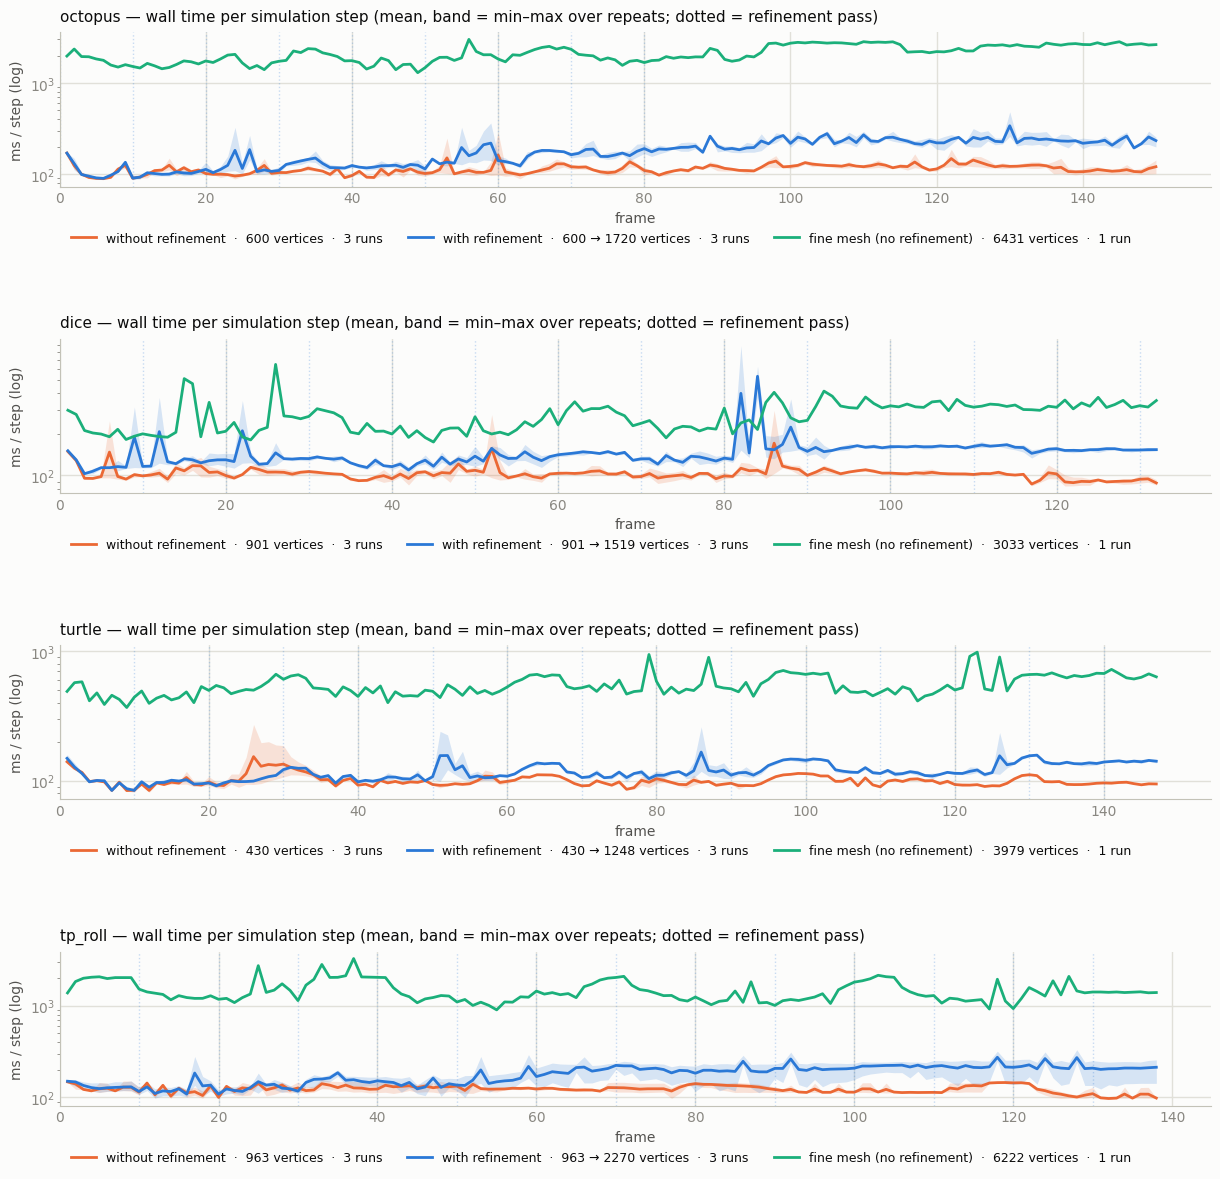

In [2]:
# --- chart style (same tokens as the loss notebooks) ---------------------
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = {
    "with refinement": "#2a78d6",
    "without refinement": "#eb6834",
    "fine mesh (no refinement)": "#1baf7a",
}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def stack(e, label):
    rows = [runs[(e, label, p)][0] for p in RUNS[e][label] if (e, label, p) in runs]
    n = min(len(r) for r in rows)
    return np.stack([r[:n] for r in rows])          # (repeats, steps)

def vert_label(e, label):
    ms, events, nverts = runs[(e, label, RUNS[e][label][0])]
    if events:   # refined run: starts from the same coarse mesh as the no-refinement run
        start = runs[(e, "without refinement", RUNS[e]["without refinement"][0])][2]
        return f"{start} → {events[-1][1]} vertices"
    return f"{nverts} vertices" if nverts else ""

# Per-step wall time. Log y-axis: the fine mesh is 10-20x the coarse mesh and a linear axis would
# flatten the with/without-refinement difference into one line.
fig, axes = plt.subplots(len(EPISODES), 1, figsize=(13, 3.0 * len(EPISODES)), squeeze=False)
for i, e in enumerate(EPISODES):
    ax = axes[i][0]
    for label in LABELS:
        S = stack(e, label)
        x = np.arange(1, S.shape[1] + 1)
        mean = S.mean(0)
        if S.shape[0] > 1:
            ax.fill_between(x, S.min(0), S.max(0), color=SERIES[label], alpha=0.18, linewidth=0)
        ax.plot(x, mean, color=SERIES[label], linewidth=2,
                label=f"{label}  ·  {vert_label(e, label)}  ·  {S.shape[0]} run{'s' if S.shape[0] > 1 else ''}")
        if label == "with refinement":
            for step, _ in runs[(e, label, RUNS[e][label][0])][1]:
                ax.axvline(step, color=SERIES[label], alpha=0.25, linewidth=1, linestyle=":")
    ax.set_yscale("log")
    ax.set_title(f"{e} — wall time per simulation step (mean, band = min–max over repeats; dotted = refinement pass)",
                 loc="left", fontsize=11, pad=8)
    ax.set_xlabel("frame"); ax.set_ylabel("ms / step (log)")
    ax.set_xlim(0, None); ax.tick_params(length=0)
    ax.legend(loc="upper left", bbox_to_anchor=(0, -0.22), frameon=False, fontsize=9, ncol=3)
fig.tight_layout(h_pad=4)
fig.savefig(ROOT / "notebooks" / "step_timing.png", dpi=130, bbox_inches="tight")
plt.show()

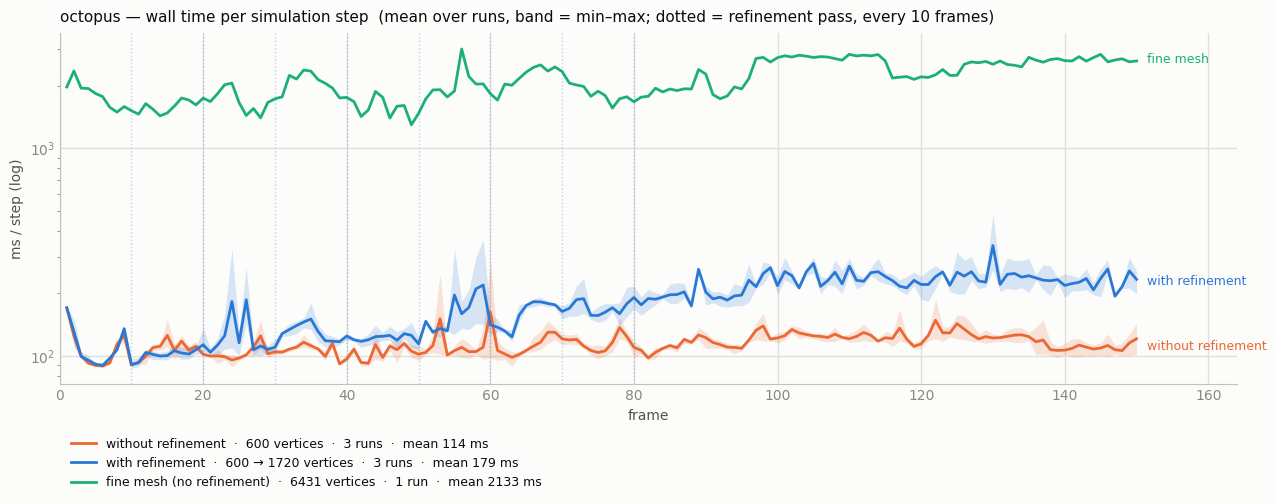

In [3]:
# Octopus only: per-step wall time for the three mesh conditions (single panel).
e = "octopus"
fig, ax = plt.subplots(figsize=(13, 5.2))
for label in LABELS:
    S = stack(e, label)
    x = np.arange(1, S.shape[1] + 1)
    if S.shape[0] > 1:
        ax.fill_between(x, S.min(0), S.max(0), color=SERIES[label], alpha=0.18, linewidth=0)
    ax.plot(x, S.mean(0), color=SERIES[label], linewidth=2,
            label=f"{label}  ·  {vert_label(e, label)}  ·  {S.shape[0]} run{'s' if S.shape[0] > 1 else ''}"
                  f"  ·  mean {S[:, 1:].mean():.0f} ms")
    # direct label at the right end
    ax.text(x[-1] + 1.5, S.mean(0)[-10:].mean(), label.split(" (")[0], color=SERIES[label],
            fontsize=9, va="center")
for step, nv in runs[(e, "with refinement", RUNS[e]["with refinement"][0])][1]:
    ax.axvline(step, color=SERIES["with refinement"], alpha=0.3, linewidth=1, linestyle=":")
ax.set_yscale("log")
ax.set_title("octopus — wall time per simulation step  (mean over runs, band = min–max; dotted = refinement pass, every 10 frames)",
             loc="left", fontsize=11, pad=8)
ax.set_xlabel("frame"); ax.set_ylabel("ms / step (log)")
ax.set_xlim(0, 164); ax.tick_params(length=0)
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.12), frameon=False, fontsize=9, ncol=1)
fig.tight_layout()
fig.savefig(ROOT / "notebooks" / "step_timing_octopus.png", dpi=130, bbox_inches="tight")
plt.show()

runs  steps  mean_ms  median_ms   max_ms  \
episode condition                                                             
octopus without refinement            3    149   114.04     112.74   287.31   
        with refinement               3    149   179.49     178.89   483.56   
        fine mesh (no refinement)     1    149  2132.95    2056.38  3008.77   
dice    without refinement            3    131   103.28     101.63   298.15   
        with refinement               3    131   147.55     141.31   883.98   
        fine mesh (no refinement)     1    131   274.44     267.90   646.10   
turtle  without refinement            3    146   100.09      96.72   271.78   
        with refinement               3    146   117.72     113.24   260.39   
        fine mesh (no refinement)     1    146   552.80     522.07   984.98   
tp_roll without refinement            3    137   123.49     119.15   158.19   
        with refinement               3    137   180.53     165.02   331.44   
        fine mesh (no refinement)     1    137  1475.47    1357.96  3273.79   

                                   total_s  total_s_min  total_s_max  x_coarse  
episode condition                                                               
octopus without refinement           16.99        16.20        17.62      1.00  
        with refinement              26.74        26.57        27.07      1.57  
        fine mesh (no refinement)   317.81       317.81       317.81     18.70  
dice    without refinement           13.53        13.19        13.86      1.00  
        with refinement              19.33        18.98        19.97      1.43  
        fine mesh (no refinement)    35.95        35.95        35.95      2.66  
turtle  without refinement           14.61        14.33        15.10      1.00  
        with refinement              17.19        17.06        17.32      1.18  
        fine mesh (no refinement)    80.71        80.71        80.71      5.52  
tp_roll without refinement           16.92        16.88        16.94      1.00  
        with refinement              24.73        20.34        27.59      1.46  
        fine mesh (no refinement)   202.14       202.14       202.14     11.95

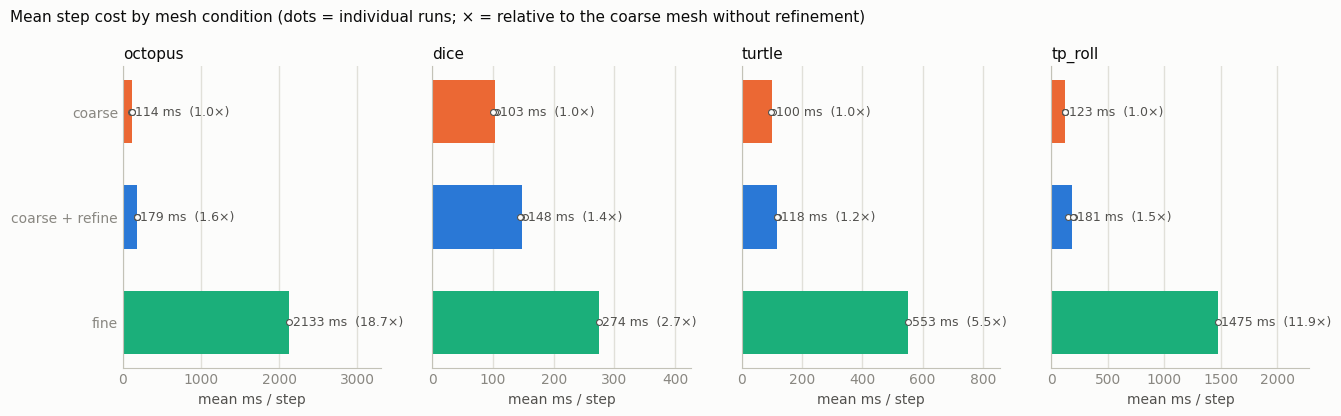

In [4]:
# Summary: mean ms/step (first step dropped) and total episode wall time per condition.
import pandas as pd
rows = []
for e in EPISODES:
    for label in LABELS:
        S = stack(e, label)[:, 1:]                 # drop warm-up step
        per_run_total = S.sum(1) / 1000.0
        rows.append(dict(episode=e, condition=label, runs=S.shape[0], steps=S.shape[1],
                         mean_ms=S.mean(), median_ms=np.median(S), max_ms=S.max(),
                         total_s=per_run_total.mean(), total_s_min=per_run_total.min(), total_s_max=per_run_total.max()))
df = pd.DataFrame(rows)
base = df[df.condition == "without refinement"].set_index("episode")["mean_ms"]
df["x_coarse"] = df.apply(lambda r: r.mean_ms / base[r.episode], axis=1)
display(df.round(2).set_index(["episode", "condition"]))

fig, axes = plt.subplots(1, len(EPISODES), figsize=(3.4 * len(EPISODES), 4.2), sharey=False)
for ax, e in zip(axes, EPISODES):
    sub = df[df.episode == e].set_index("condition").loc[LABELS]
    y = np.arange(len(LABELS))
    ax.barh(y, sub.mean_ms, color=[SERIES[l] for l in LABELS], height=0.6)
    for k, l in enumerate(LABELS):
        S = stack(e, l)[:, 1:]
        ax.scatter(S.mean(1), np.full(S.shape[0], y[k]), color=SURFACE, edgecolor=INK2, s=18, zorder=3, linewidth=0.8)
        ax.text(max(sub.mean_ms[l], S.mean(1).max()) + 0.02 * sub.mean_ms.max(), y[k],
                f"{sub.mean_ms[l]:.0f} ms  ({sub.x_coarse[l]:.1f}×)", va="center", fontsize=9, color=INK2)
    ax.set_xlim(0, sub.mean_ms.max() * 1.55)
    ax.set_yticks(y); ax.set_yticklabels(["coarse", "coarse + refine", "fine"] if ax is axes[0] else [])
    ax.invert_yaxis(); ax.tick_params(length=0); ax.grid(axis="y", visible=False)
    ax.set_title(e, loc="left", fontsize=11); ax.set_xlabel("mean ms / step")
fig.suptitle("Mean step cost by mesh condition (dots = individual runs; × = relative to the coarse mesh without refinement)",
             x=0.01, ha="left", fontsize=11)
fig.tight_layout()
fig.savefig(ROOT / "notebooks" / "step_timing_summary.png", dpi=130, bbox_inches="tight")
plt.show()

**Observations (2026-09-11).**

- **Refinement costs +18% to +57% per step on average** (turtle 1.2×, dice 1.4×, tp_roll 1.5×, octopus 1.6×) and
  the overhead grows through the episode as the mesh grows: once the refined mesh has reached its final size
  (2–3× the coarse vertex count) a step costs roughly 2× the unrefined step. The refinement pass itself
  (dotted lines, every 10 frames) is visible as isolated spikes of 2–5× on the frame it fires (dice ~900 ms
  at frames 82–85) but is a small share of the total.
- **The fine mesh costs 2.7× (dice) to 19× (octopus) per step.** For octopus and tp_roll, whose fine meshes
  have ~6.2–6.4k vertices, a step takes 1.5–2.1 s versus ~0.11 s coarse and ~0.18 s coarse + refinement, so the
  whole 150-frame episode is ~5 min fine vs ~27 s refined vs ~17 s coarse. The fine-mesh cost is superlinear in
  vertex count (octopus: 10.7× the vertices, 18.7× the time), consistent with the global solve dominating.
- Taken together with `refinement_loss*.ipynb`: refinement recovers a large part of the discretisation error
  (−54% MSE vs the fine simulation on octopus, −57% on turtle) for ~1.5× the coarse cost, i.e. ~10× cheaper
  than the fine mesh it is compared against on the two large episodes.
- Caveats: single fine run per episode (no repeat band); the fine reference for octopus is `fine_default`
  (same iterations/substeps as the coarse runs — see `reference_runs/fine_converged.log` for the converged-solver
  cost, ~16 s/step); timings include the recording readback.